In [1]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Excitation 1s2 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination of cross sections and oscillator strengths for argon by electron-energy-loss spectroscopy. Physical Review A, 38(3), 1240–1247. https://doi.org/10.1103/PhysRevA.38.1240
396.8786575783061
11.828
109


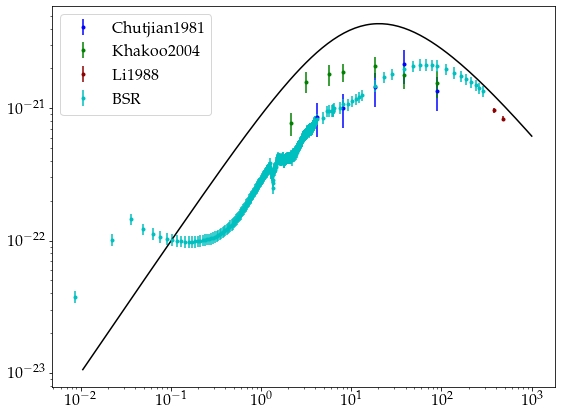

In [14]:
from models import *
level = 4
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>3e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([2.54e-1,0.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_resonance_modified(4,theta_ref,Etest)
mask = model0 > 1.0e-23
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="upper left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


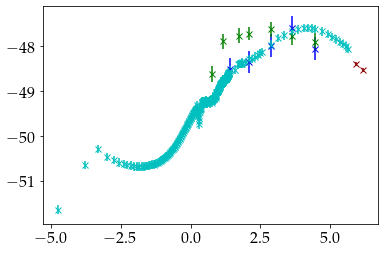

In [15]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])

In [16]:
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [17]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

torch.float64 torch.float64


### Bayesian inference

In [9]:
from models import *

def log_prior(theta):
#     if ((theta[0]<=0.0) or (theta[1]>=1.0e1) or (theta[2]>=1.0e1)):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
#     if ((theta[0]<=0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([2.54e-1])
#     theta_ref = np.array([51.2e0,2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:1] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
#     print('kern: ',theta[-2:])
    
    lk = 0.0
    for k in range(len(Wlog)):
#         if((k!=4)): continue
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
#         logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )            
#         logModel = np.log( Excite_resonance(level,theta[:2],W[k][:,0]) )
        logModel = np.log( Excite_resonance_modified(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
#         print(theta[:1],logModel, yd[k])
#         print(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
#         lk += - 0.5 * torch.dot(dev,cov_inv_y).detach().numpy()
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
#     print(lp,lk)
#     if (np.isinf(lk) or np.isinf(lp)):
#         print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [18]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e-1, 0.3, 1.0, 0.1])
# theta_ref = np.array([51.2e0,2.0,1.0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [19]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  1%|▎                                                     | 3/500 [00:00<00:16, 29.40it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_86152/2226793348.py:38: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance_modified(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.97it/s]


[26.96551676 25.14214536 32.06253089 34.07601293]


100%|████████████████████████████████████████████████████| 500/500 [00:16<00:00, 29.49it/s]


[39.50323134 45.12974182 49.28425955 45.96588982]


100%|████████████████████████████████████████████████████| 500/500 [00:16<00:00, 29.80it/s]


...

[51.8194698  56.9446086  70.98594197 65.10228004]


100%|████████████████████████████████████████████████████| 500/500 [00:16<00:00, 30.53it/s]


[52.45027028 57.02913525 69.97483337 65.17021601]


100%|████████████████████████████████████████████████████| 500/500 [00:16<00:00, 31.04it/s]


[52.80746021 57.05314886 69.51931698 64.57427065]


(5984, 4)


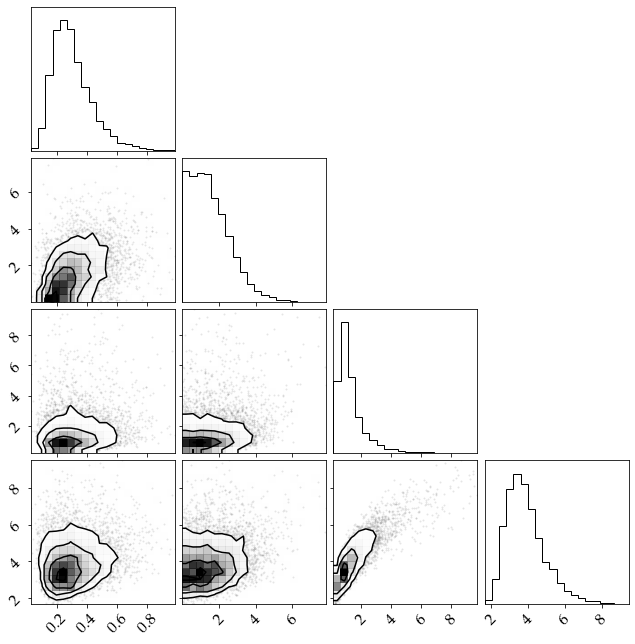

In [23]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s2.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
fig.savefig("./excitation.1s2.corner.pdf", dpi=1200)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


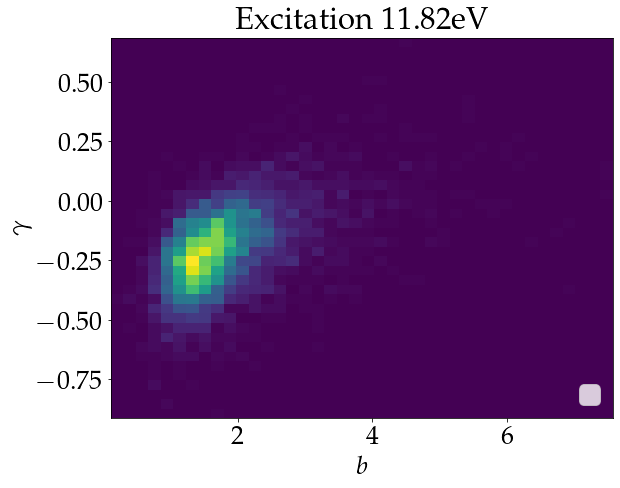

(array([[1., 2., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.]]),
 array([0.24922854, 0.48461269, 0.71999684, 0.95538099, 1.19076514,
        1.42614929, 1.66153344, 1.89691759, 2.13230174, 2.36768589,
        2.60307004, 2.83845419, 3.07383834, 3.30922249, 3.54460664,
        3.77999079, 4.01537494, 4.25075908, 4.48614323, 4.72152738,
        4.95691153, 5.19229568, 5.42767983, 5.66306398, 5.89844813,
        6.13383228, 6.36921643, 6.60460058, 6.83998473, 7.07536888,
        7.31075303, 7.54613718, 7.78152133, 8.01690548, 8.25228963,
        8.48767378, 8.72305793, 8.95844208, 9.19382623, 9.42921038,
        9.66459453]),
 array([-0.43087763, -0.37769759, -0.32451755, -0.27133751, -0.21815748,
        -0.16497744, -0.1117974 , -0.05861737, -0.00543733,  0.04774271,
         0.10092275,  0.15410278,  0.20

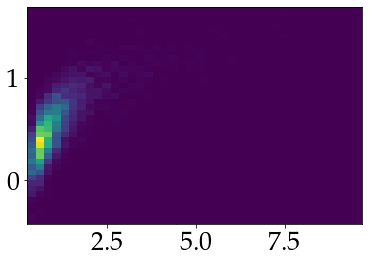

In [31]:
plt.figure(1)
plt.hist2d(flat_samples[:,0],flat_samples[:,1],bins=40)
plt.plot(theta_ref[0],theta_ref[1],'or',markersize=10)
# plt.xlim([0, 400])
# plt.ylim([0, 3.0])
plt.xlabel('$b$')
plt.ylabel('$\gamma$')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 26,
})

plt.title('Excitation 11.82eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.pdf", dpi=1200)

plt.figure(2)
plt.hist2d(flat_samples[:,-2],np.log(flat_samples[:,-1]),bins=40)

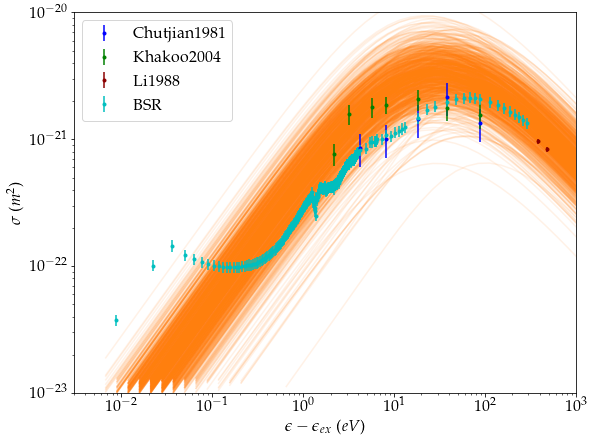

In [22]:
Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
#     models = Excite_metastable(level,sample[:2],Etest)
    models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./excitation.1s2.modified.curve1.pdf", dpi=1200)

dev:  61.89972227252355
tensor(36.3482)
dev:  18.976049738650993
tensor(13.5780)
dev:  9.971727062349945
tensor(12.0170)
-48.22528079667528 -36.840216739571204 -36.059698956147315
tensor([[1.0074e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.2161e-04, 1.0074e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.2275e-05, 2.9066e-01, 9.6460e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [4.8967e-40, 4.4089e-35, 5.1691e-34,  ..., 9.4596e-01, 0.0000e+00,
         0.0000e+00],
        [5.7123e-41, 5.1587e-36, 6.0529e-35,  ..., 3.5812e-01, 9.3931e-01,
         0.0000e+00],
        [8.8629e-42, 8.0240e-37, 9.4208e-36,  ..., 8.7784e-02, 4.3272e-01,
         9.0543e-01]])


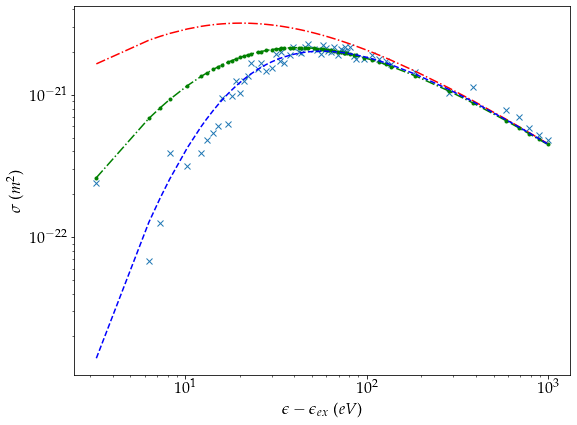

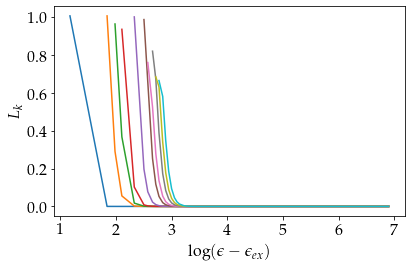

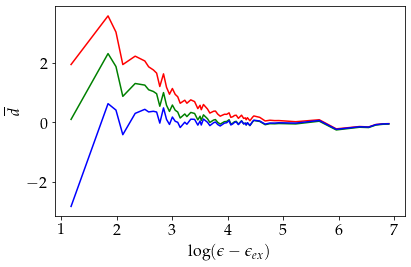

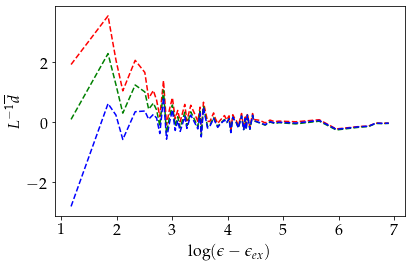

In [188]:
cov_kern.var[0], cov_kern.scale[0] = 1.0, 1.0e-1

lk1 = 0.0
for k in range(len(Wlog)):
    if((k!=2)): continue
    cov = cov_kern.forward(0,torch.tensor(xd[k]))
    cov += torch.diag(torch.tensor(ed[k]**2))
#     try:
    LKb = torch.linalg.cholesky(cov)
#     except RuntimeError:
#         return - np.inf

    logModel1 = np.log( Excite_resonance(level,[2.54e0, 0.0e0],W[k][:,0]) )
    dev1 = logModel1 - yd[k]
    print('dev: ', np.sum(dev1**2))
    dev = torch.tensor(dev1)
    cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb,upper=False).reshape(-1)
    Linv_y1, dummy = torch.triangular_solve(dev.reshape(dev.size(0),1),LKb,upper=False)
    print(torch.sum(Linv_y1**2))
    
    temp = - 0.5 * torch.dot(dev,cov_inv_y)
    temp += - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
    lk1 += temp.detach().numpy()
    
lk2 = 0.0
for k in range(len(Wlog)):
    if((k!=2)): continue
#     cov = cov_kern.forward(0,torch.tensor(xd[k],dtype=torch.float))
#     cov += torch.diag(torch.tensor(ed[k]**2,dtype=torch.float))
# #     try:
#     LKb = torch.linalg.cholesky(cov)
# #     except RuntimeError:
# #         return - np.inf

    logModel2 = np.log( Excite_resonance(level,[2.54e0, 1.2e0],W[k][:,0]) )
    dev2 = logModel2 - yd[k]
    print('dev: ', np.sum(dev2**2))
    dev = torch.tensor(dev2)
    cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb,upper=False).reshape(-1)
    Linv_y2, dummy = torch.triangular_solve(dev.reshape(dev.size(0),1),LKb,upper=False)
    print(torch.sum(Linv_y2**2))
    
    temp = - 0.5 * torch.dot(dev,cov_inv_y)
    temp += - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
    lk2 += temp.detach().numpy()
    
lk3 = 0.0
for k in range(len(Wlog)):
    if((k!=2)): continue
#     cov = cov_kern.forward(0,torch.tensor(xd[k],dtype=torch.float))
#     cov += torch.diag(torch.tensor(ed[k]**2,dtype=torch.float))
# #     try:
#     LKb = torch.linalg.cholesky(cov)
# #     except RuntimeError:
# #         return - np.inf

    logModel3 = np.log( Excite_resonance(level,[2.54e0, 4.2, 1.6],W[k][:,0]) )
    dev3 = logModel3 - yd[k]
#     dev[0] = 0.0
#     dev[1:] *= 1e3
#     dev = yd[k] - yd[k]
    print('dev: ', np.sum(dev3**2))
    dev = torch.tensor(dev3)
    cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb,upper=False).reshape(-1)
    Linv_y3, dummy = torch.triangular_solve(dev.reshape(dev.size(0),1),LKb,upper=False)
    print(torch.sum(Linv_y3**2))
    
#     print('right?: ', dev3 - torch.matmul(LKb,Linv_y3).reshape(-1))
    temp = - 0.5 * torch.dot(dev,cov_inv_y)
#     print(temp)
    temp += - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
    lk3 += temp.detach().numpy()
    
print(lk1,lk2,lk3)
print(LKb)
plt.figure(1)
# plt.plot(xm[0],yd[0],'x')
plt.plot(np.exp(xm[2]),np.exp(yd[2]),'x')
plt.plot(np.exp(xm[2]),np.exp(logModel1),'-.r')
plt.plot(np.exp(xm[2]),np.exp(logModel2),'-..g')
plt.plot(np.exp(xm[2]),np.exp(logModel3),'--b')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
# plt.ylim([1e-23, 1e-20])
# plt.xlim([3e-3, 1e3])
# plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.demo.models.pdf", dpi=1200)

# eigval, eigvec = torch.linalg.eig(cov)
plt.figure(2)
for k in range(10):
    plt.plot(xm[2][k:],LKb[k:,k].detach(),'-')
plt.xlabel('$\log(\epsilon-\epsilon_{ex})$')
plt.ylabel('$L_k$')
plt.tight_layout()
fig = plt.gcf()
# fig.savefig("./excitation.1s2.demo.L.short.pdf", dpi=1200)

plt.figure(3)
plt.plot(xm[2],dev1,'-r')
plt.plot(xm[2],dev2,'-g')
plt.plot(xm[2],dev3,'-b')
plt.xlabel('$\log(\epsilon-\epsilon_{ex})$')
plt.ylabel('$\overline{d}$')
plt.tight_layout()
fig = plt.gcf()
# fig.savefig("./excitation.1s2.demo.dev.short.pdf", dpi=1200)

plt.figure(4)
plt.plot(xm[2],Linv_y1,'--r')
plt.plot(xm[2],Linv_y2,'--g')
plt.plot(xm[2],Linv_y3,'--b')
plt.xlabel('$\log(\epsilon-\epsilon_{ex})$')
plt.ylabel('$L^{-1}\overline{d}$')
plt.tight_layout()
fig = plt.gcf()
# fig.savefig("./excitation.1s2.demo.Linv.short.pdf", dpi=1200)

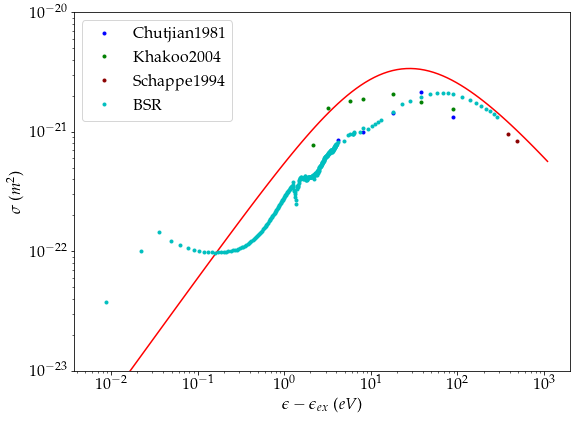

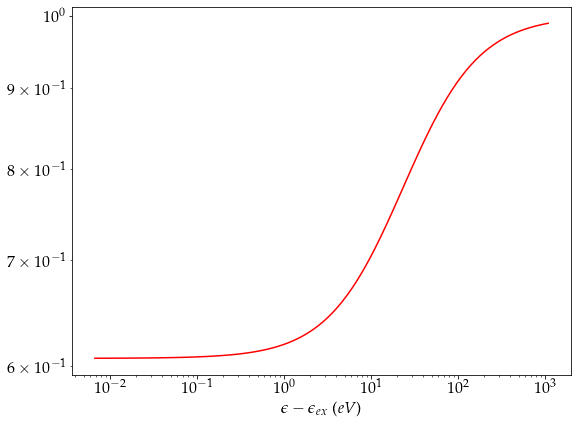

In [22]:
def Excite_model(n,theta,E):
#     from models import *
    
#     F0, beta, alpha0, C1 = theta
    F0, beta = theta
#     beta = 1.0
    C1 = 1.0
        
    v2 = qe * E * 2.0 / me
    beta2 = v2 / c0 / c0
    # relativistic factor
    rel_factor = np.log(1.0 / (1.0 - beta2) * E / E_ext[n-1] * C1 ) - beta2
#     emp_factor = ( 1.0 - (E_ext[n-1]/E)**alpha0 ) ** beta
#     emp_factor = beta * (0.5 + 0.5 * np.tanh( alpha0 - np.log( (E/E_ext[n-1]) - 1.0 ) ) )
#     emp_factor = np.exp(emp_factor)
    emp_factor = np.exp( - beta / (1.0 + E/E_ext[level-1]) )
#     rel_factor = np.log(beta2 / (1.0 - beta2) * mc2 / 2.0 / E_ext[n-1] ) - beta2
#     largeE_factor = 0.5 * (1.0 + C1) + 0.5 * (C1 - 1.0) * np.tanh( beta*(E - alpha0 - E_ext[n-1]) )
    return 4. * np.pi * a0 * a0 * R0 * R0 / E * F0 / E_ext[n-1] * rel_factor * emp_factor
#     return 4. * np.pi * a0 * a0 * R0 / E * F0 / E_ext[n-1] * rel_factor * largeE_factor

xtest = np.linspace(-5,7,100)
Etest = np.exp(xtest) + E_ext[level-1]
logModel1 = np.log( Excite_model(level,[2.54e-1, 1.],Etest) )
    
plt.figure(1)
plt.plot(Etest-E_ext[level-1],np.exp(logModel1),'-r')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
    plt.plot(Wk[:,0] - E_ext[level-1],np.exp(yd[k]),'.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-23, 1e-20])
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.no-empirical.pdf", dpi=1200)

plt.figure(1)
plt.plot(Etest-E_ext[level-1],np.exp( - 1.0 / (1.0 + Etest/E_ext[level-1]) ),'-r')
plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-23, 1e-20])
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.tight_layout()
# plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()

tensor(-49.0228)


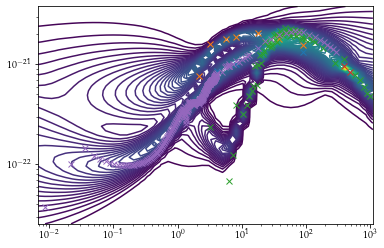

In [397]:
def max_corr(kernels,n,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
#     for k in range(kernels.n):
    varm = kernels.forward(n, xm-xm)
    vart = kernels.forward(n, xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernels.covariance(n,xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

Ntest = 50
xtest = torch.linspace(-5,7,Ntest)
sigmatest = torch.linspace(-3,2,Ntest)
maxcor_sum = torch.zeros_like(xtest)
ym, y_var, zm = [], [], []
for k in range(len(Wlog)):
    Kb = cov_kern.forward(k,xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    Kb += torch.diag(ed[k]**2)
    Kp = cov_kern.covariance(k,xm[k],xtest)
    
    LKb = torch.cholesky(Kb)
    ym += [torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]
    y_cov = cov_kern.covariance(k,xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    y_var += [torch.diag(y_cov)]
    
    zm += [max_corr(cov_kern,k,xm[k],xtest)]
    maxcor_sum += zm[k]
    
for zk in zm:
    zk /= maxcor_sum
    
xx, ss = np.meshgrid(xtest.detach(),sigmatest.detach())
pp = np.zeros_like(xx)
for k in range(len(Wlog)):
#     if (k!=0): continue
    yym, tmp = np.meshgrid(ym[k].detach(),sigmatest.detach())
    yyvar, tmp = np.meshgrid(y_var[k].detach(),sigmatest.detach())
    zz, tmp = np.meshgrid(zm[k].detach(),sigmatest.detach())
    
    pp += np.exp( - 0.5 * (ss - yym)**2 / yyvar ) / np.sqrt(2.0 * np.pi * yyvar) * zz
    
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# from matplotlib import cm
# ax.plot_surface(xx, ss, pp,
#                 cmap=cm.coolwarm, linewidth=0)
# ax.view_init(90, -90)
# ax.dist = 5
print(Wlogm)
plt.figure(1)
plt.contour(np.exp(xx),np.exp(ss+float(Wlogm.detach())),pp,100)
for k, wlogk in enumerate(Wlog):
    plt.plot(np.exp(wlogk[:,0]),np.exp(wlogk[:,1]+float(Wlogm.detach())),'x')
plt.xscale('log')
plt.yscale('log')

# temp = np.exp(xx)[:]
# temp.tofile('./xx.dat')
# temp = np.exp(ss + float(Wlogm.detach()))[:]
# temp.tofile('./ss.dat')
# temp = np.exp(pp)[:]
# temp.tofile('./pp.dat')
# temp = np.copy(Wlog[-1][:,:2])
# temp[:,0] = np.exp(temp[:,0])
# temp[:,1] = np.exp(temp[:,1]+float(Wlogm.detach()))
# temp.tofile('./BSR.excite.4.dat')

In [326]:
# cov_kern = MaternPack(len(Wlog),nu=1.5)
cov_kern = ExpKernelPack(len(Wlog))
# cov_kern = ExpTanhKernel()

optimizer = torch.optim.LBFGS(cov_kern.parameters(),lr=1e-4)

# def likelihoodEntropy(kernel):
#     lk = 0.0
    
#     for k in range(len(Wlog)):
#         cov = kernel.forward(xd[k])
# #         cov = kernel.forward(xd[k],xm[k])
#         cov += torch.diag(ed[k]**2)
# #         print(cov)
#         Lcov = torch.cholesky(cov)
#         cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
#         lk += - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#     return lk * torch.exp(lk)

def likelihoodEntropy(kernels):
    ent = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         cov = kernel.forward(xd[k],xm[k])
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk = - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#         if (k==2): lk *= 0.2
        ent += lk * torch.exp(lk)
    return ent

def closure():
    lk = likelihoodEntropy(cov_kern)
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    lk = likelihoodEntropy(cov_kern)
    if t % 100 == 99:
        print(t, lk.item())

    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
for name, param in cov_kern.named_parameters():
    if param.requires_grad:
        print(name, param.data)

99 -0.7566540837287903
199 -0.756799578666687
299 -0.756821870803833
399 -0.7568576335906982
499 -0.7569053173065186
599 -0.7569378614425659
699 -0.7569611668586731
799 -0.7569963932037354
899 -0.7570253610610962
999 -0.7570655345916748
var tensor([1.0670, 1.0313, 0.8809, 1.0525, 1.0068])
scale tensor([1.0810, 1.0570, 0.9087, 0.7940, 0.8963])


torch.Size([5, 5]) torch.Size([5, 50])
tensor([0.0543, 0.0535, 0.0523, 0.0503, 0.0477, 0.0443, 0.0403, 0.0362, 0.0321,
        0.0286, 0.0259, 0.0241, 0.0231, 0.0227, 0.0228, 0.0232, 0.0235, 0.0238,
        0.0239, 0.0239, 0.0237, 0.0236, 0.0235, 0.0235, 0.0236, 0.0238, 0.0241,
        0.0244, 0.0246, 0.0250, 0.0256, 0.0267, 0.0287, 0.0315, 0.0350, 0.0390,
        0.0429, 0.0465, 0.0494, 0.0516, 0.0531, 0.0541, 0.0547, 0.0550, 0.0551,
        0.0552, 0.0552, 0.0552, 0.0552, 0.0553], grad_fn=<DiagBackward0>)
torch.Size([50])
Parameter containing:
tensor(0.0553, requires_grad=True) Parameter containing:
tensor(1.2113, requires_grad=True)


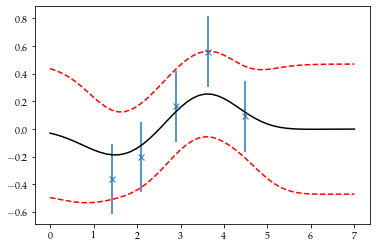

In [116]:
Kd = []
for k in range(len(Wlog)):
    cov = cov_kern.forward(xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    cov += torch.diag(ed[k]**2)
    Kd += [cov]
Kb = torch.block_diag(*Kd)
Kp = cov_kern.covariance(wlogx,xtest)
print(Kb.size(),Kp.size())

LKb = torch.cholesky(Kb)
ym = torch.matmul( Kp.t(), torch.cholesky_solve(wlogy.reshape(wlogy.size(0),1),LKb) ).squeeze()
y_cov = cov_kern.covariance(xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
y_var = torch.diag(y_cov)
print(y_var)
print((ym + torch.sqrt(y_var)).size())
print(cov_kern.var,cov_kern.scale)
# print(cov_kern.var1,cov_kern.var2,cov_kern.slope,cov_kern.phase)

plt.figure(1)
for wlogk in Wlog:
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')
plt.plot(xtest,ym.detach(),'-k')
plt.plot(xtest,(ym + 2.0 * torch.sqrt(y_var)).detach(),'--r')
plt.plot(xtest,(ym - 2.0 * torch.sqrt(y_var)).detach(),'--r')

In [319]:
def max_corr(kernel,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
    varm = kernel.forward(xm-xm)
    vart = kernel.forward(xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernel.covariance(xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

xtest = torch.linspace(0.,5.0,100)

plt.figure(1)
plt.plot(xtest, max_corr(cov_kern,xm[0],xtest).detach(),'-')
plt.plot(xm[0], max_corr(cov_kern,xm[0],xm[0]).detach(),'x')

TypeError: forward() missing 1 required positional argument: 'xd'

<Figure size 432x288 with 0 Axes>

In [430]:
# wcov_inv = np.linalg.inv(wcov)
# wcov_det = np.linalg.det(wcov)

Etest = np.exp(xtest.detach().numpy()) + E_ext[3]
Wm = float(Wlogm.detach())
Ym, Y_var, Zm = [], [], []
for k in range(len(Wlog)):
    Ym += [ym[k].detach().numpy()]
    Y_var += [y_var[k].detach().numpy()]
    Zm += [zm[k].detach().numpy()]

def log_prior_ext4(theta):
    return 0.0
#     if (theta[0]<=0.0):
#         return - np.inf
#     theta_ref = np.array([2.54e0,1.0,1.0,1.0])
#     sigma2 = ( 1.0 * theta_ref )**2
# #     sigma2[-1] = 0.5
#     return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )


def log_likelihood_ext4(theta):
    # compute log-normal probability
    n = 4
    logModel = np.log( Excite_resonance(n,theta,Etest) )
    lk = 0.0
    for k in range(len(Wlog)):
        dev = logModel - Wm - Ym[k]
        lk += np.exp( - 0.5 * dev**2 / Y_var[k] ) / np.sqrt(2.0 * np.pi * Y_var[k]) * Zm[k]

    return np.sum(np.log(lk))

def log_posterior_ext4(theta):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta)
#     print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

# def log_posterior_ext4(theta, W):
#     lp = log_prior_ext4(theta)
#     lk = 0.0
#     for Wk in W:
#         temp = log_likelihood_ext4(theta, Wk[:,0], Wk[:,1], Wk[:,2])
# #         lk += np.exp(temp)
#         lk += temp
# #     lk = np.log(lk)
#     if (not np.isfinite(lp)) or (not np.isfinite(lk)):
#         return - np.inf
#     return lp + lk


# lk = np.zeros(len(W))
# for k, Wk in enumerate(W):
#     lk[k] = log_likelihood_ext4(theta_ref, Wk[:,0], Wk[:,1], Wk[:,2])
# plt.figure(1)
# plt.plot(lk,'o')

In [437]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 1.0 * np.random.randn(nwalkers,ndim) )
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4
)
sampler.run_mcmc(pos, 30000, progress=True);

tau = sampler.get_autocorr_time(tol=0)
print(tau)

/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:41: RuntimeWarning: invalid value encountered in log
  rel_factor = np.log(beta2 / (1.0 - beta2) * mc2 / 2.0 / E_ext[n-1] * C1 ) - beta2
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16710/3984685034.py:25: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(n,theta,Etest) )
/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:42: RuntimeWarning: invalid value encountered in power
  return 4. * np.pi * a0 * a0 * R0 / E * F0 / E_ext[n-1] * rel_factor * ( 1.0 - (E_ext[n-1]/E) ** alpha0 ) ** beta
  0%|                                                 | 0/30000 [00:00<?, ?it/s]/opt/homebrew/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16710/3984685034.py:31: RuntimeWarning: divide by zero encountered in log
  r

[1985.12480394  741.69015928  918.00561527 1351.7984661 ]


In [438]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
print(flat_samples.shape)

# tmp = flat_samples,
# tmp.tofile('../crs-Bayes1/crs.excitation.level4.withBSR.modified.dat')

(2240, 4)


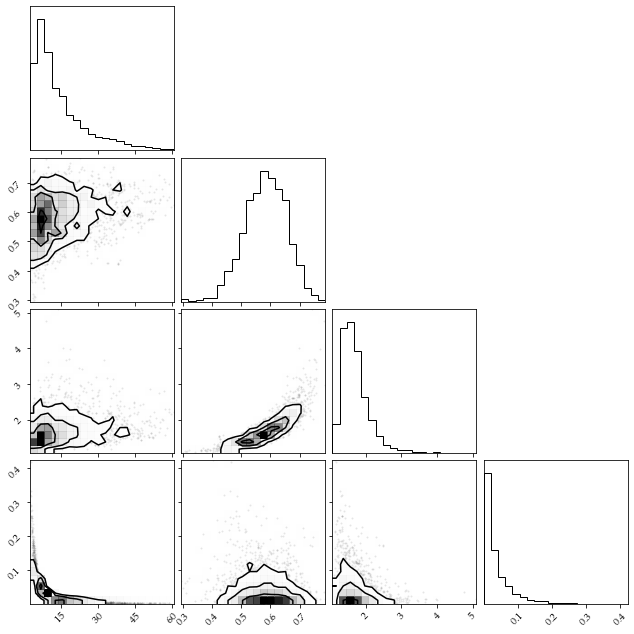

In [439]:
import corner

fig = corner.corner(flat_samples);

(0.01, 1000.0)

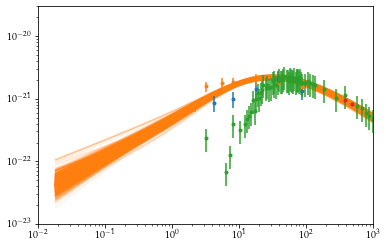

In [440]:
Nw = 50
wtest = np.linspace(-4,7.,Nw)
Etest = np.exp(wtest) + E_ext[3]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_resonance(4,sample,Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[3], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for Wk in W[:-1]:
    plt.errorbar(Wk[:,0]-E_ext[3],Wk[:,1],yerr=Wk[:,2],fmt='.')
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-23, 3e-20])
plt.xlim([1e-2, 1e3])

## Excitation 1s4 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & 

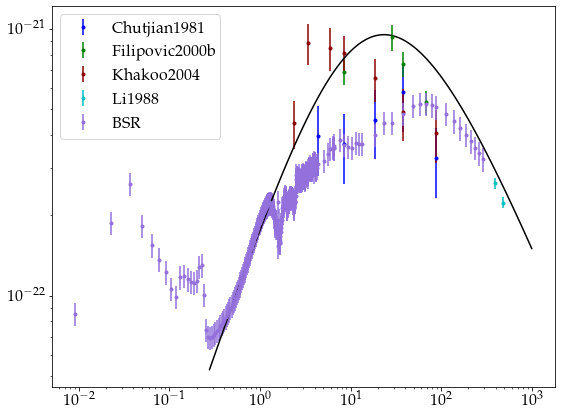

In [25]:
from models import *
level = 2
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([0.61e-1,0.5])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_resonance_modified(level,theta_ref,Etest)
# model0 = Excite_resonance(4,theta_ref,Etest)
mask = model0 > 5.0e-23
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="upper left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


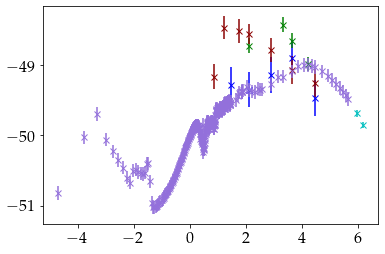

In [26]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

### Bayesian inference

In [27]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([0.61e-1])
    sigma2 = ( 1.0 * theta_ref )**2
    sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:1] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( Excite_resonance_modified(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [28]:
import emcee
nwalkers = 32
theta_ref = np.array([0.61e-1, 0.5, 1.0, 0.1])
# theta_ref = np.array([51.2e0,2.0,1.0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [29]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  2%|▉                                                     | 9/500 [00:00<00:18, 26.48it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_86152/1615700308.py:36: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance_modified(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:18<00:00, 27.45it/s]


[48.22890537 34.28736572 26.56677221 61.74836957]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.27it/s]


[82.97427902 59.3786079  41.8261863  90.12662916]


100%|████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.52it/s]


...

[96.64307104 72.15491407 59.87786312 83.75518036]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.12it/s]


[92.75649988 73.2066757  62.94045272 83.58149036]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.16it/s]


[90.03015727 72.31149295 65.17442936 84.85889154]


(4800, 4)


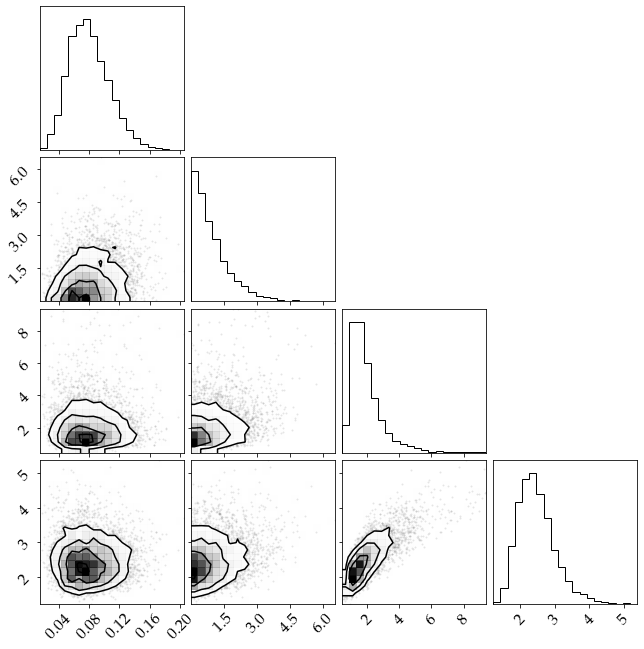

In [33]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s4.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
fig.savefig("./excitation.1s4.corner.pdf", dpi=1200)

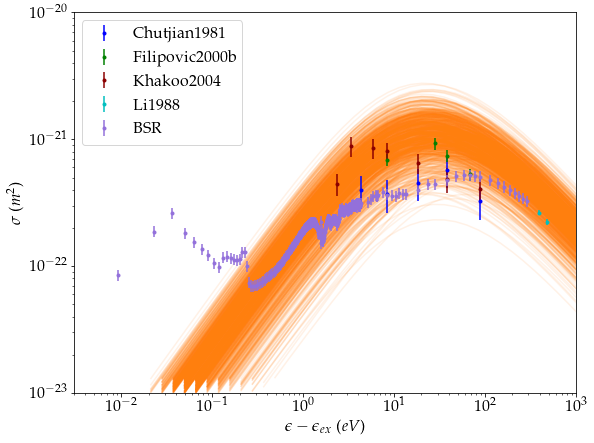

In [32]:
Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
#     models = Excite_metastable(level,sample[:2],Etest)
    models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./excitation.1s4.curve.pdf", dpi=1200)

## Excitation 1s5 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

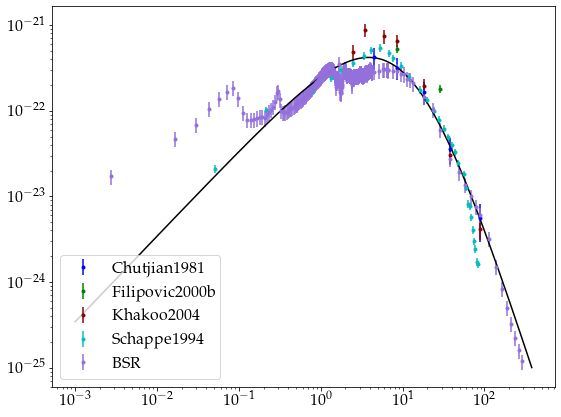

In [42]:
from models import *
level = 1
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([51.2e0,2.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


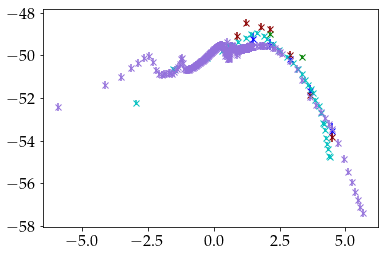

In [43]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [37]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([51.2e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [44]:
import emcee
nwalkers = 32
theta_ref = np.array([51.2e0,2.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [45]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  5%|██▌                                                  | 24/500 [00:01<00:19, 23.89it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_86152/3735580568.py:36: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.58it/s]


[25.98649054 32.10418985 32.84517431 40.55924156]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.02it/s]


[34.20319977 38.95186921 49.01078989 48.59042745]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.19it/s]


...

[46.92585702 46.15473499 64.29574491 52.92311892]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.54it/s]


[48.27087783 46.3402365  64.99151639 52.37141636]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.43it/s]


[48.3037314  48.00901398 63.97335454 52.51608816]


(6496, 4)


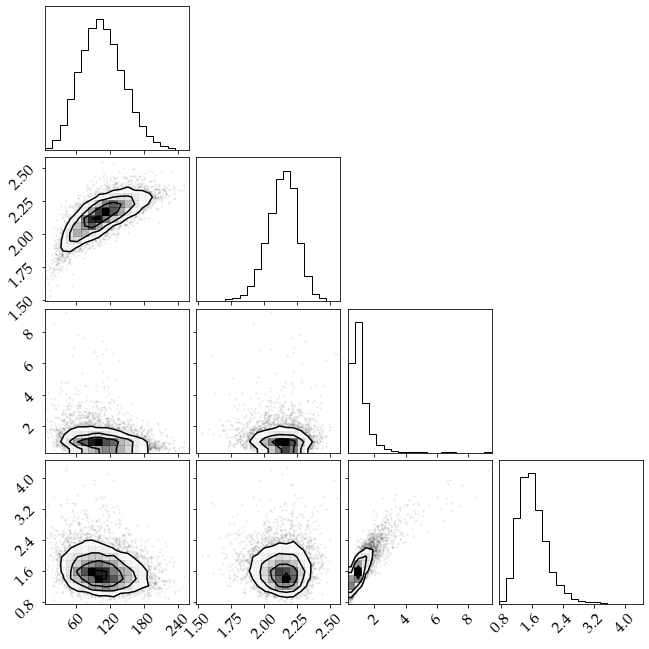

In [46]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
# tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s5.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

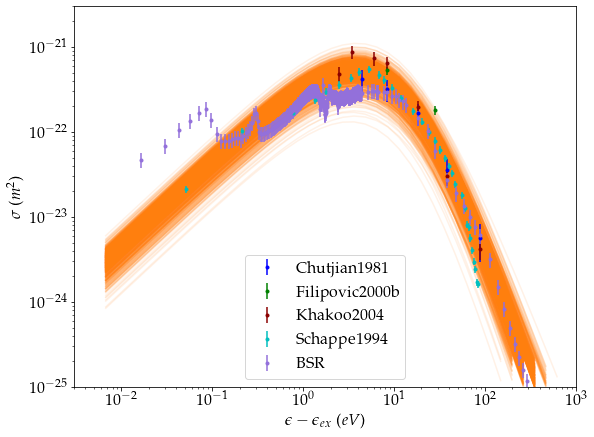

In [49]:
Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
#     models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s5.curve.pdf", dpi=1200)

## Excitation 1s3 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

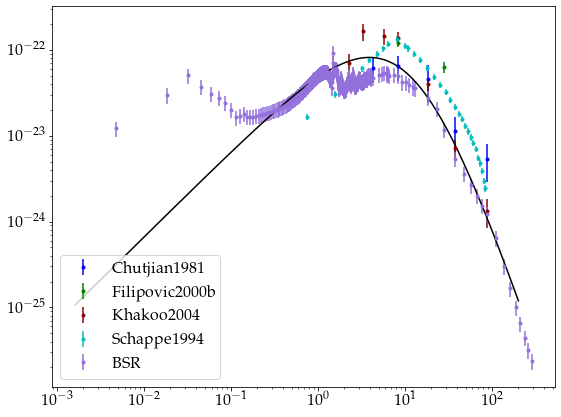

In [126]:
from models import *
level = 3
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([10.4e0,2.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


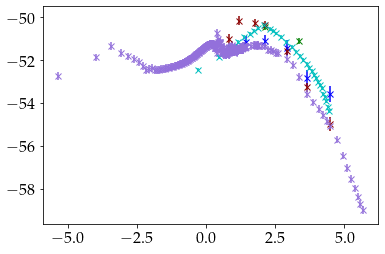

In [127]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [249]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([10.4e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [250]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4e0,2.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [251]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  1%|▋                                                     | 6/500 [00:00<00:17, 28.57it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_83655/844000950.py:36: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.15it/s]


[27.78766669 27.36509584 27.69779442 42.0780578 ]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 27.86it/s]


[34.17228154 32.50256717 38.30232251 47.69991695]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.60it/s]


...

[55.10427264 48.61495036 69.27000842 64.97837776]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 29.19it/s]


[56.10788281 49.91317953 69.02601726 65.38838597]


100%|████████████████████████████████████████████████████| 500/500 [00:17<00:00, 28.95it/s]


[58.47552485 50.93001836 70.90586562 65.30369068]


(6208, 4)


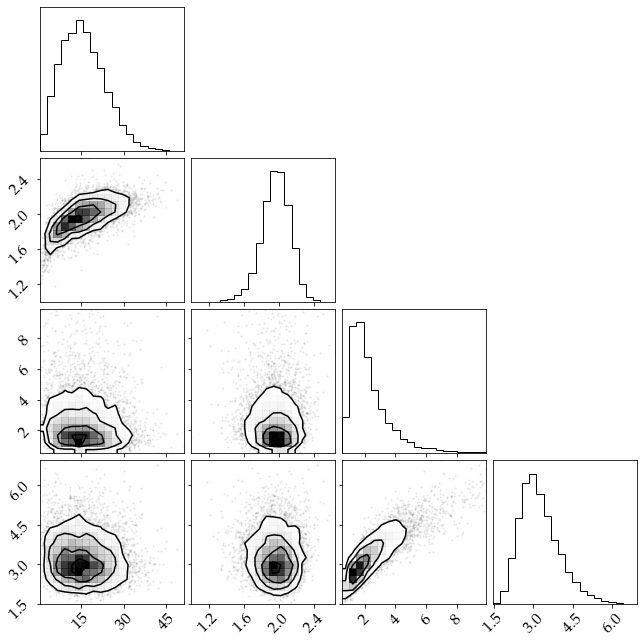

In [252]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
# tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

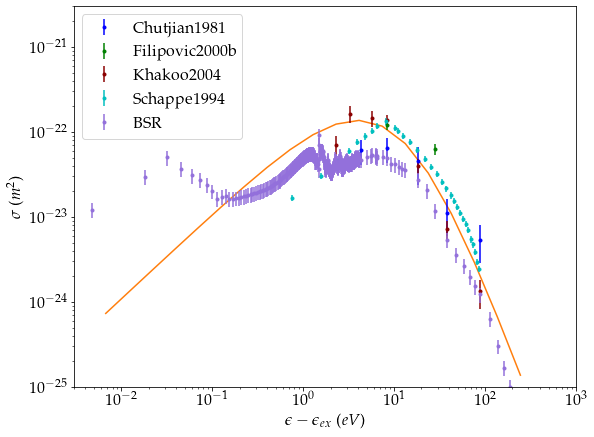

In [146]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples), size=1)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
#     models = Excite_resonance_modified(level,sample[:2],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

## Ionization

Rapp, D., & Englander-Golden, P. (1965). Total cross sections for lonization and attachment in gases by electron impact. I. Positive ionization. The Journal of Chemical Physics, 43(5), 1464–1479. https://doi.org/10.1063/1.1696957
1000.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
20.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
20.0
Wetzel, R. C., Baiocchi, F. A., Hayes, T. R., & Freund, R. S. (1987). Absolute cross sections for electron-impact ionization of the rare-gas atoms by the fast-neutral-beam method. Physical Review A, 35(2), 559

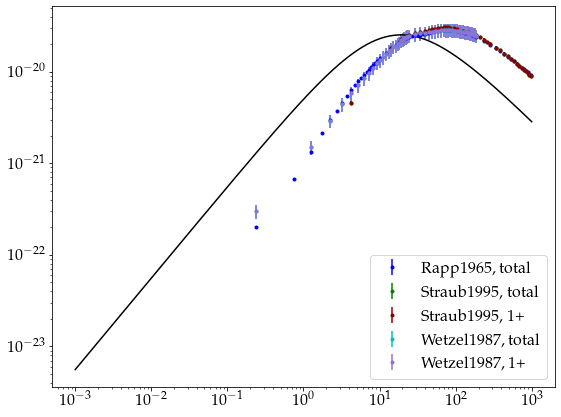

<Figure size 432x288 with 0 Axes>

In [118]:
from models import *
level = 1
dataType1 = crs.typeDictS2I['Ionization, '+str(level)+'+']
dataType = crs.typeDictS2I['Ionization, total']
threshold = np.floor(10*E_ion[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]+', total']
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
    if dataType1 in swarm.datasets:
        targetrefs += [refs[k]+', 1+']
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# # Include BSR dataset, except the first entry (excitation level).
# for c in BSR.crs:
#     if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
#         targetrefs += ['BSR']
# #         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
# #         temp = np.copy(c.data[mask,:])
#         temp = np.copy(c.data[1:,:])
#         error = temp[:,1][...,None] * 0.2
#         temp = np.append( temp, error, axis=1)
#         print(c.deltaE)
#         print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
#         W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([1.0, 1.0, 1.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ion[level-1]
model0 = total_Ion_BED(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ion[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
plt.savefig('./ionization.png',dpi=1200)


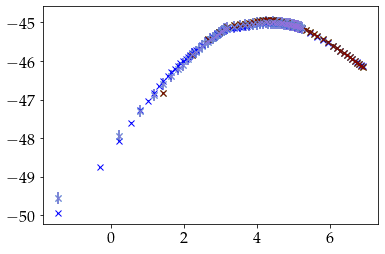

In [119]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ion[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [102]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    lp = 0.0
#     if ((theta[0]<=0.0) or (theta[1]<0.0)):
#         return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
#     theta_ref = np.array([10.4e0, 2.0])
#     sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
#     lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        logModel = np.log( total_Ion_BED(theta[:3],W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [103]:
import emcee
nwalkers = 32
theta_ref = np.array([1.0,1.0,1.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [106]:
# sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 65.11it/s]


[135.07352092  72.6238789   85.32660215 221.79642869 282.08436807]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 66.02it/s]


[135.19721426  72.66567091  85.39857243 222.07324564 281.39752171]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 65.47it/s]


...

[135.74166622  72.89174199  85.75624785 223.27956946 277.19981729]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 63.82it/s]


[135.81531384  72.90042278  85.77090836 223.41597672 276.23663357]


100%|████████████████████████████████████████████████████| 500/500 [00:07<00:00, 66.08it/s]


[135.88005529  72.90564584  85.78207635 223.54734976 276.31128955]


(12832, 5)


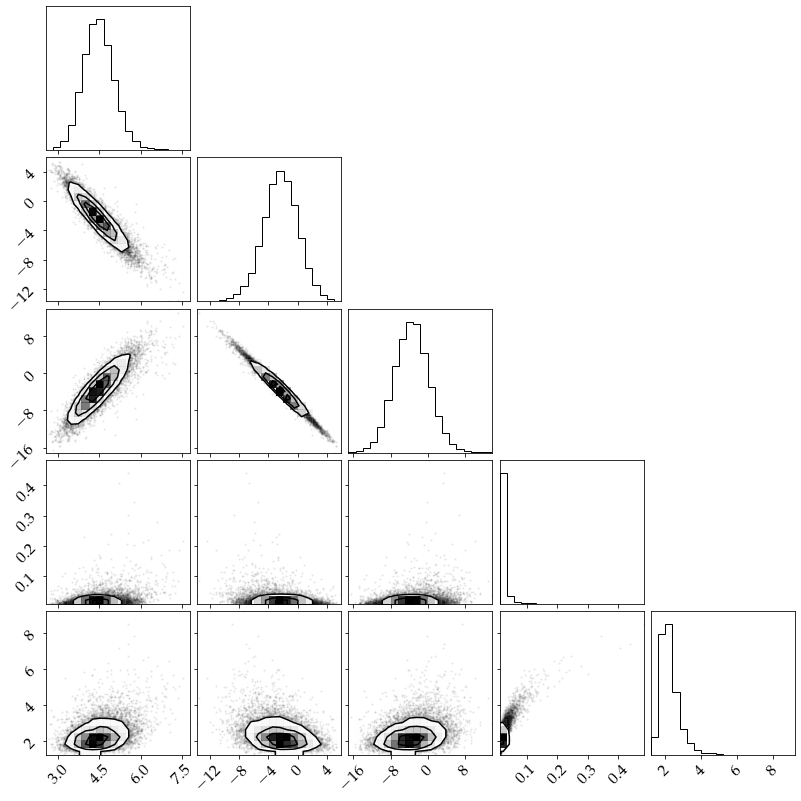

In [114]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.ionization.total.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
fig.savefig("./ionization.total.corner.pdf", dpi=1200)

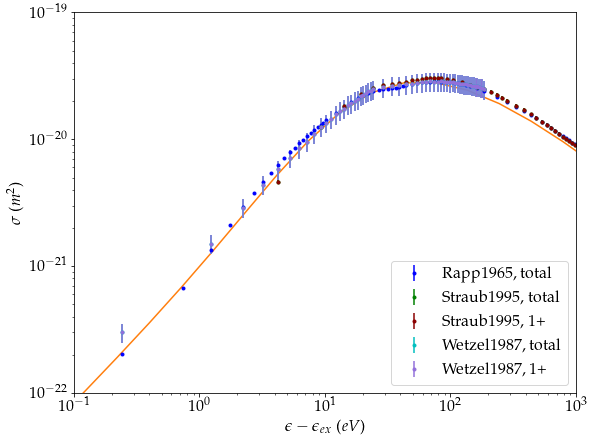

In [123]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.ionization.total.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/5), 5])

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ion[level-1]

inds = np.random.randint(len(flat_samples), size=1)
for ind in inds:
    sample = flat_samples[ind]
    models = total_Ion_BED(sample[:3],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask]-E_ion[level-1], models[mask], "C1", alpha=1)

for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-22, 1e-19])
plt.xlim([1e-1, 1e3])
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./ionization.total.curve.pdf", dpi=1200)

## Elastic momentum

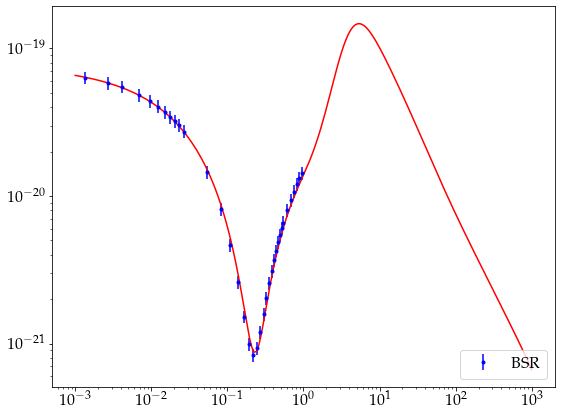

In [6]:
from models import *
dataType = crs.typeDictS2I['Elastic, momentum']


targetrefs = []

W = []
# for k, swarm in enumerate(swarms):
#     if dataType in swarm.datasets:
#         targetrefs += [refs[k]+', total']
#         print(swarm.ref)
#         temp = np.copy(swarm.datasets[dataType].data)
# #         mask = temp[:,0] <= 1.0
# #         temp = np.copy(temp[mask,:])
#         W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==0)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        mask = temp[:,0] <= 1.0
        temp = np.copy(temp[mask,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
#         print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([-1.488, 65.4, -84.3, 0.883])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest
model0 = elastic_MERT(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,model0,'-r')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.pdf", dpi=600)
# plt.savefig('./elastic.png',dpi=1200)


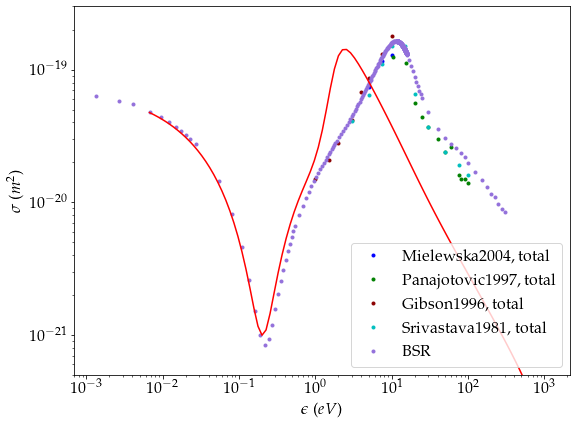

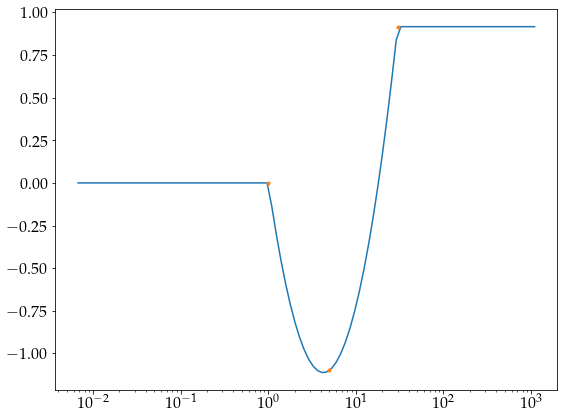

In [99]:
import scipy.interpolate as interpolate

def Elastic_model(theta,E_input,N=10):
    NE = len(E_input)
    E = np.copy(E_input)
    
    A, D, F, E1, t1, t2, t3 = theta
    
#     xx = np.array([0., np.log(5.0), np.log(10.0)])
#     yy = np.array([0., -np.log(2.0), np.log(2.5)])
#     tt, cc, kk = interpolate.splrep(xx, yy, s=0, k=2)
#     spline = interpolate.BSpline(tt, cc, kk, extrapolate=True)
#     emp_factor = np.zeros((NE,))
#     mask = (E<1.0)
#     emp_factor[mask] = 0.0
#     mask = (E>10.0)
#     emp_factor[mask] = spline(np.log(10.0))
#     mask = ( (E>=1.0) & (E<=10.0) )
#     emp_factor[mask] = spline(np.log(E[mask]))
#     tmp = ( E / t1 ) ** t2
#     kk = t3
#     E *= 0.5 * (1.0 + kk) - 0.5 * (1.0 - kk) * ( tmp - 1.0 ) / ( tmp + 1.0 )
    E *= 0.5*(1.+t1) - 0.5 * (1. - t1) * np.tanh( (E - t2) / t3 )
    
    k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
    crs = np.zeros((NE,))

#     A, D, F, E1 = theta
    eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
    eta0 = np.arctan(eta0 * k)

    eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
    eta1 = np.arctan(eta1 * k)

    crs += np.sin(eta0 - eta1)**2

    for L in range(1,N):
        eta0 = np.copy(eta1)
        L1 = L+1
        eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
        eta1 = np.arctan(eta1 * k)
        
        crs += (L + 1.) * np.sin(eta0 - eta1)**2

    return crs * 4. * np.pi / k / k * a0 * a0

xtest = np.linspace(-5,7,100)
Etest = np.exp(xtest)
logModel1 = np.log( Elastic_model([-1.488, 65.4, -84.3, 0.983, 2.5, 1.5,1.0],Etest) )
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,np.exp(logModel1),'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.no-empirical.pdf", dpi=1200)

# plt.figure(1)
# plt.plot(Etest-E_ext[level-1],np.exp( - 1.0 / (1.0 + Etest/E_ext[level-1]) ),'-r')
# plt.xscale('log')
# plt.yscale('log')
# # plt.ylim([1e-23, 1e-20])
# plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
# plt.tight_layout()
# # plt.legend()
# fig = plt.gcf()
# fig.set_size_inches(9, 7)
# plt.show()

xx = np.array([0., np.log(5.0), np.log(30.0)])
yy = np.array([0., -np.log(3.0), np.log(2.5)])
tt, cc, kk = interpolate.splrep(xx, yy, s=0, k=2)
spline = interpolate.BSpline(tt, cc, kk, extrapolate=True)
emp_factor = np.zeros((100,))
mask = (Etest<1.0)
emp_factor[mask] = 0.0
mask = (Etest>30.0)
emp_factor[mask] = spline(np.log(30.0))
mask = ( (Etest>=1.0) & (Etest<=30.0) )
emp_factor[mask] = spline(np.log(Etest[mask]))

plt.figure(2)
plt.plot(Etest,emp_factor,'-')
plt.plot(np.exp(xx),yy,'.')
plt.xscale('log')
fig = plt.gcf()
fig.set_size_inches(9, 7)

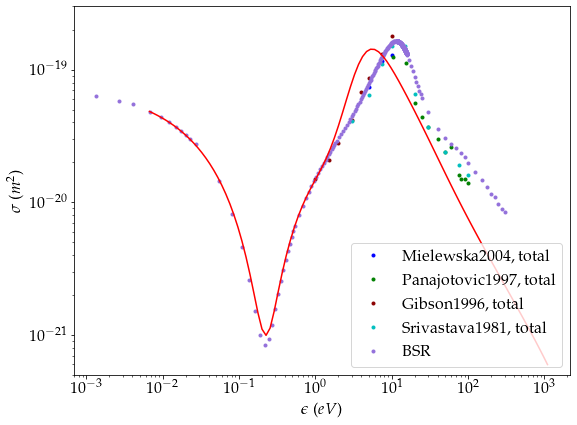

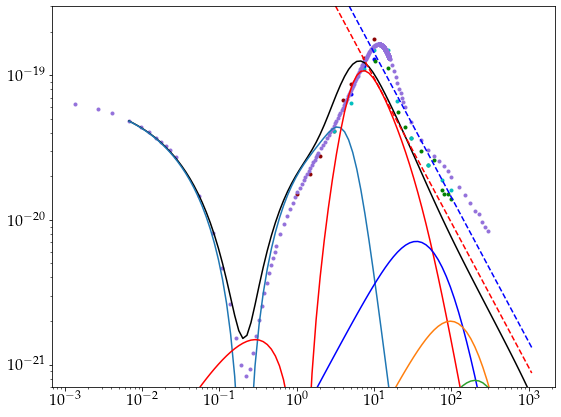

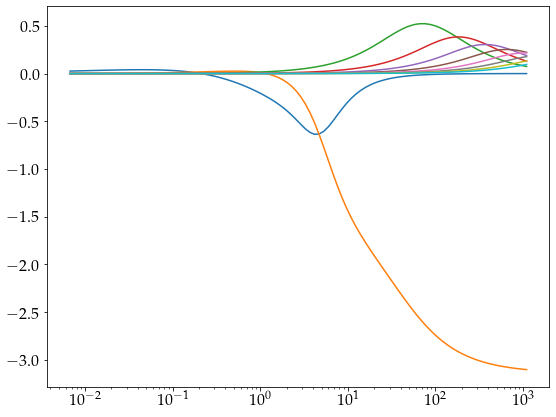

In [69]:
import scipy.interpolate as interpolate

def Elastic_model(theta,E_input,N=10):
    NE = len(E_input)
    E = np.copy(E_input)
    
    A, D, F, E1, t1, t2 = theta
    
    k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
    crs = np.zeros((NE,))

#     A, D, F, E1 = theta
    eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
    eta0 = np.arctan(eta0 * k)

    eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
    eta1 = np.arctan(eta1 * k)

    crs += np.sin(eta0 - eta1)**2

    for L in range(1,N):
        eta0 = np.copy(eta1)
        L1 = L+1
        eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
        eta1 = np.arctan(eta1 * k)
        
        if (L==1):
            crs += t1 * (L + 1.) * np.sin(eta0 - eta1)**2            
        else:
            crs += (L + 1.) * np.sin(eta0 - eta1)**2

    return crs * 4. * np.pi / k / k * a0 * a0

xtest = np.linspace(-5,7,100)
Etest = np.exp(xtest)
theta_ref = [-1.488, 65.4, -84.3, 0.983, 1.0]
logModel1 = np.log( Elastic_model(theta_ref,Etest) )
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,np.exp(logModel1),'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.no-empirical.pdf", dpi=1200)

NE = len(Etest)
Nk = 10
E = np.copy(Etest)

theta_ref = [-1.488, 65.4, -84.3, 1.583, 1.0]
A, D, F, E1, t1 = theta_ref

k = np.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
crs = np.zeros((NE,))
crsk = np.zeros([NE,Nk])
detak = np.zeros([NE,Nk])

#     A, D, F, E1 = theta
eta0 = - A * ( 1. + 4. / 3. * alpha * k * k * np.log(k) ) - np.pi / 3. * alpha * k + D * k**2 + F * k**3
eta0 = np.arctan(eta0 * k)

eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
# eta1 -= 2.5 * k ** 3
eta1 = np.arctan(eta1 * k)

detak[:,0] = eta0 - eta1
crsk[:,0] = np.sin(eta0 - eta1)**2
crs += crsk[:,0]

for L in range(1,Nk):
    eta0 = np.copy(eta1)
    L1 = L+1
    eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
#     if(L==2): eta1 += 0.5 * k ** 3
    eta1 = np.arctan(eta1 * k)
    detak[:,L] = eta0 - eta1

    if (L==2):
        crsk[:,L] = t1 * (L + 1.) * np.sin(detak[:,L])**2
        crs += crsk[:,L]
    else:
        crsk[:,L] = (L + 1.) * np.sin(detak[:,L])**2
        crs += crsk[:,L]

crs *= 4. * np.pi / k / k * a0 * a0
for kk in range(Nk):
    crsk[:,kk] *= 4. * np.pi / k / k * a0 * a0

plt.figure(2)
for kk, Wk in enumerate(W):
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[kk],label=targetrefs[kk])
plt.plot(Etest,crs,'-k')
for kk in range(Nk):
    if(kk==1):
        plt.plot(Etest,crsk[:,kk],'-r')
        plt.plot(Etest,4.*np.pi/k/k*a0*a0*(kk+1.),'--r')
    elif(kk==2):
        plt.plot(Etest,crsk[:,kk],'-b')
        plt.plot(Etest,4.*np.pi/k/k*a0*a0*(kk+1.),'--b')
    else:
        plt.plot(Etest,crsk[:,kk],'-')
plt.xscale('log')
plt.yscale('log')
plt.ylim([7e-22, 3e-19])
fig = plt.gcf()
fig.set_size_inches(9, 7)

plt.figure(3)
for kk in range(Nk):
    plt.plot(Etest,detak[:,kk],'-')
plt.xscale('log')
fig = plt.gcf()
fig.set_size_inches(9, 7)

In [100]:
import torch
from models import *

targetW = torch.tensor(W[4])

class MERT(torch.nn.Module):
    def __init__(self, theta):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        A, D, F, E1, t1, t2, t3 = theta
        self.A = torch.nn.Parameter(torch.tensor(A))
        self.D = torch.nn.Parameter(torch.tensor(D))
        self.F = torch.nn.Parameter(torch.tensor(F))
        self.E1 = torch.nn.Parameter(torch.tensor(E1))
        self.t1 = torch.nn.Parameter(torch.tensor(t1))
        self.t2 = torch.nn.Parameter(torch.tensor(t2))
        self.t3 = torch.nn.Parameter(torch.tensor(t3))
        self.N = 10

    def forward(self):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        
        E = torch.clone(targetW[:,0])
        E *= 0.5*(1.+self.t1) - 0.5 * (1. - self.t1) * torch.tanh( (E - self.t2) / self.t3 )
#         E = targetW[:,0] * ( 0.5*(1.+self.t1) - 0.5 * (1. - self.t1) * torch.tanh( targetW[:,0] / self.t2 - 1.0 ) ) * torch.exp( (targetW[:,0] / self.t2)**self.t3 )
#         E = targetW[:,0] * ( 1.0 + self.t3*(targetW[:,0]/self.t2 - 1.0) / (1.0 + torch.exp(-self.t1*(targetW[:,0]/self.t2 - 1.0))) )
#         emp_factor = ( 1.0 + E / self.t2 ) ** self.t3
        NE = len(E)

        k = torch.sqrt( E / Efromk2 ) # wavenumber in a0^(-1)
        crs = torch.zeros((NE,))

    #     A, D, F, E1 = theta
        eta0 = - self.A * ( 1. + 4. / 3. * alpha * k * k * torch.log(k) ) - np.pi / 3. * alpha * k + self.D * k**2 + self.F * k**3
        eta0 = torch.arctan(eta0 * k)

        eta1 = np.pi / 15. * alpha * k * ( 1. - torch.sqrt(E/self.E1) )
#         eta1 += self.t2 * k**3
        eta1 = torch.arctan(eta1 * k)

        crs += torch.sin(eta0 - eta1)**2

        for L in range(1,self.N):
            eta0 = torch.clone(eta1)
            L1 = L+1
            eta1 = np.pi * alpha * k / (2.*L1 + 3.) / (2.*L1 + 1.) / (2.*L1 - 1.)
#             if(L==2):
#                 eta1 += self.t1 * k**3
#             elif(L==2):
#                 eta1 += self.t2 * k**3
#             elif(L==3):
#                 eta1 += self.t3 * k**3
            eta1 = torch.arctan(eta1 * k)

            crs += (L + 1.) * torch.sin(eta0 - eta1)**2

        crs *= 4. * np.pi / k / k * a0 * a0
        
        return crs
#         return torch.sum( (torch.log(crs) - torch.log(targetW[:,1]))**2 )

# [-1.44, 54.97, -69.50, 0.70, 0.43, 0.43, 0.68
theta_ref = [-1.488, 65.4, -84.3, 1.583, 0.5, 0.5, 0.5]
model = MERT(theta_ref)

optimizer = torch.optim.LBFGS(model.parameters(),lr=1e-3)
    
def closure():
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    crs_model = model.forward()
    lk = torch.sum( (torch.log(crs_model) - torch.log(targetW[:,1]))**2 )
    if t % 100 == 99:
        print(t, lk.item())

    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
theta_opt = []
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)
        theta_opt += [float(param.data)]
print(theta_opt)

99 3.1325183990824566
199 2.7684305428586
299 2.761048740336789
399 2.760495395910196
499 2.760481498704299
599 2.760481410794726
699 2.7604813386796727
799 2.760481279513157
899 2.760481230963582
999 2.7604811911205616
A tensor(-1.4173)
D tensor(62.5606)
F tensor(-85.2020)
E1 tensor(0.7361)
t1 tensor(0.4464)
t2 tensor(1.6510)
t3 tensor(2.0011)
[-1.4173003748675717, 62.56060131992609, -85.20199010031428, 0.7361486757602836, 0.4463721552135573, 1.6509904643360198, 2.001074057955869]


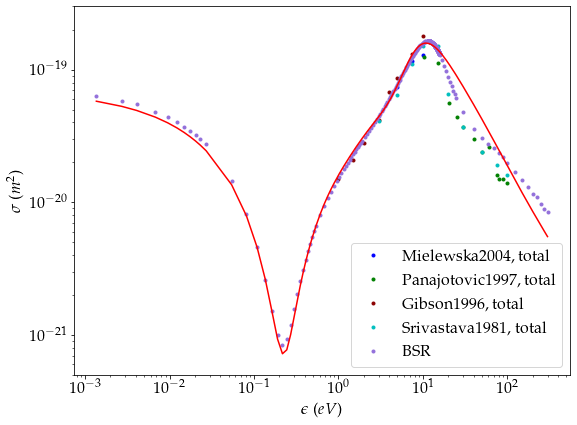

In [101]:
# model.t3 = torch.nn.Parameter(torch.tensor(-0.05))
model1 = model.forward().detach().numpy()
    
plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(targetW[:,0].detach().numpy(),model1,'-r')
plt.xscale('log')
plt.yscale('log')
plt.ylim([5e-22, 3e-19])
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()

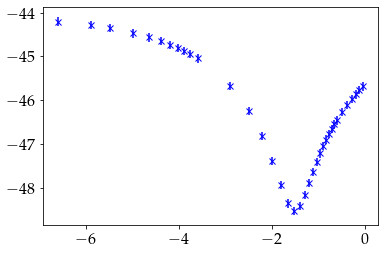

In [7]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [8]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    lp = 0.0
#     if ((theta[5]<=0.1) or (theta[5]>10.0) or (theta[4]<=0.0) or (theta[4]>=1.0) or (theta[6]<=1.0e-2) or (theta[6]>10.0)):
#         return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([-1.488, 65.4, -84.3, 0.983])
    sigma2 = ( 0.5 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (theta[:4] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
#     lp += - np.log(theta[5]) - np.log(np.log(1e1) - np.log(0.1e0))
#     lp += - np.log(theta[6]) - np.log(np.log(1e1) - np.log(1e-2))
#     lp += - np.log(theta[5]) - np.log(np.log(5.0) - np.log(0.2))
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
#         logModel = np.log( Elastic_model(theta[:7],W[k][:,0]) )
        logModel = np.log( elastic_MERT(theta[:4],W[k][:,0]) )
#         print(len(W[k][:,0]), logModel.shape)
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [9]:
import emcee
nwalkers = 32
theta_ref = np.array([-1.488, 65.4, -84.3, 0.983, 1.0, 0.1])
# theta_ref = np.array([-1.488, 65.4, -84.3, 0.983, 2.5, 1.5, 0.5, 1.0, 0.1])
# theta_ref = np.array([-1.44, 54.97, -69.50, 0.70, 0.43, 0.43, 0.68, 1.0, 0.1])
# theta_ref = np.array([-1.42, 57.73, -77.36, 0.73, 0.44, 0.51, 1.0, 0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
)

In [10]:
sampler.run_mcmc(pos, 1);

for k in range(30):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

  7%|███▌                                                | 34/500 [00:00<00:02, 158.10it/s]/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:94: RuntimeWarning: invalid value encountered in sqrt
  eta1 = np.pi / 15. * alpha * k * ( 1. - np.sqrt(E/E1) )
100%|███████████████████████████████████████████████████| 500/500 [00:04<00:00, 115.40it/s]


[37.78784296 36.3990994  35.55674551 41.37729569 38.22914423 62.90649647]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 90.08it/s]


[ 57.94347722  55.95285305  54.86739145  59.8980164   44.14950486
 128.06841815]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 92.43it/s]


...

[160.62475631 148.46864534 156.5805855  226.72709767 210.54858668
 257.47047108]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 88.07it/s]


[160.08023435 147.15892378 155.21992795 224.08589035 212.51154075
 258.24366167]


100%|████████████████████████████████████████████████████| 500/500 [00:05<00:00, 91.40it/s]


[159.13336974 146.6143343  154.34514186 223.9607049  211.86261842
 259.13713314]


(5954, 6)


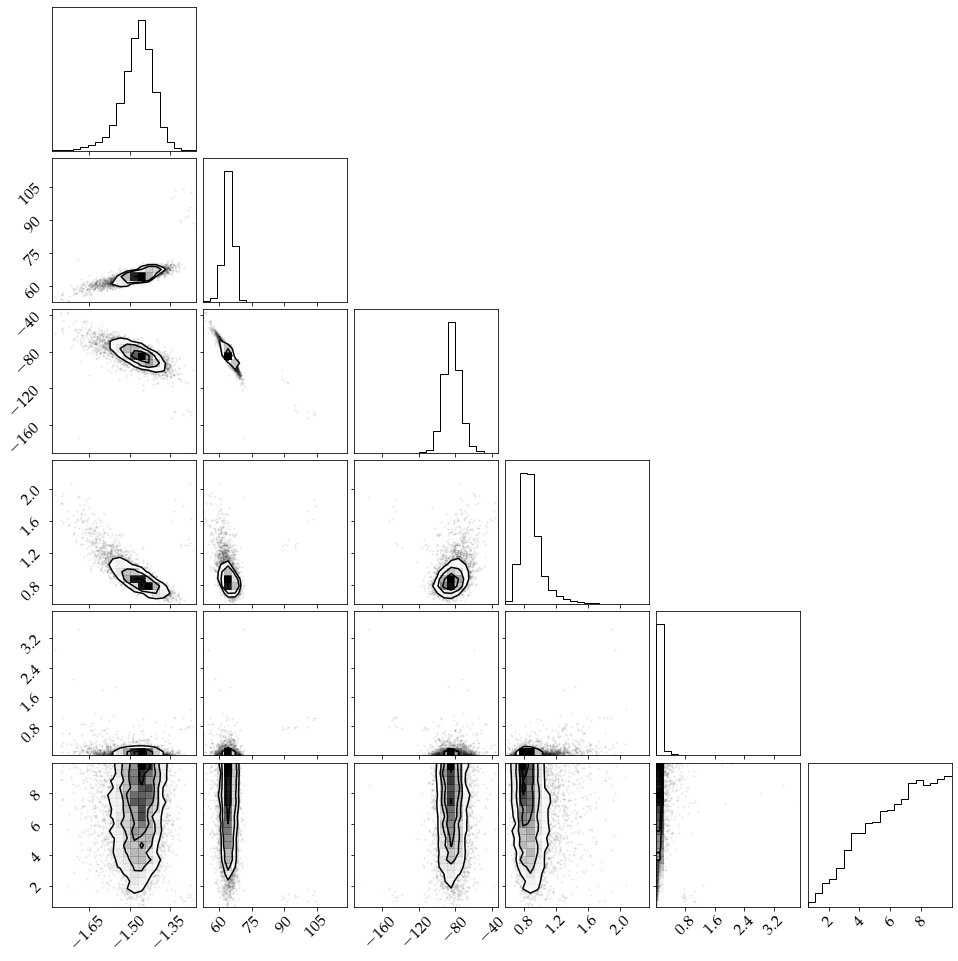

In [15]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
mask = flat_samples[:,0]<-1.25
flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);

# tmp.tofile('../crs-Bayes-gpr/without-swarm/crs.elastic.7param.dat')
# fig.savefig("./elastic.corner.pdf", dpi=600)

7.889476089940829e-20


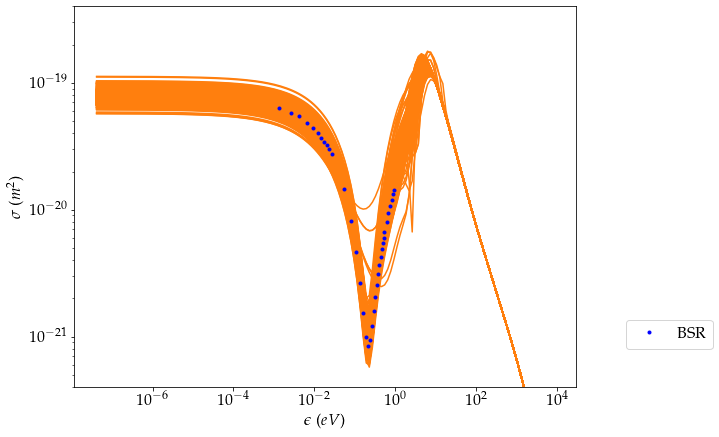

In [16]:
# flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.elastic.7param.dat')
# flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/9), 9])

Nw = 150
wtest = np.linspace(-17,9.,Nw)
Etest = np.exp(wtest)

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
#     models = Elastic_model(sample[:7],Etest)
    models = elastic_MERT(sample[:4],Etest)
    mask = models > 1.0e-25
    plt.plot(Etest[mask], models[mask], "C1", alpha=1)
print(models[0])
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
#     plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')

# fig.savefig("./elastic.curve.1.pdf", dpi=1200)

# for k, lxcat in enumerate(datasets[:-2]):
#     filename = './crs/%s.txt' % lxcat
#     tmp = cross.multipleCrossSections(filename)
#     for c in tmp.crs:
#         if ((c.colType==0)):
#             plt.plot(c.data[:,0], c.data[:,1],'-',label=lxcat)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([4e-22, 4e-19])
# plt.xlim([1e-3, 1e3])
plt.legend(loc=(1.1,0.1))
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.curve.with-lxcats.pdf", dpi=1200)

In [152]:
x = np.array([[0,1]])
y = np.array([[1,2],[3,4]])
z = np.append(x,y,axis=0)
print(x)
print(x.shape)
print(y)
print(z)

[[0 1]]
(1, 2)
[[1 2]
 [3 4]]
[[0 1]
 [1 2]
 [3 4]]
